Training Temporal GRU Autoencoder for Imputation...
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Training Survival GRU...
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
------------------------------
C-Index: 0.8535
Sensitivity (Recall): 0.8550 [0.821, 0.884]
Specificity         : 0.8433 [0.832, 0.854]
PPV (Precision)     : 0.3959 [0.366, 0.426]
NPV                 : 0.9798 [0.974, 0.984]
Balanced Accuracy   : 0.8492 [0.838, 0.859]

Metric                              | Value      | Category
-----------------------------------------------------------------
Alerts per 100 Patient-Visits       | 18.3       | Clinical Burden
Proportion of Visits in Alert       | 18.31%     | Alarm Density
Median TIW (True Positives)         | 181.0 days | Lead Time
Median TIW (False Positives)        | 59.0 days  | Noise Duration


Slope: 0.8252 | Intercept: -0.1785 | R-sq: 0.8350


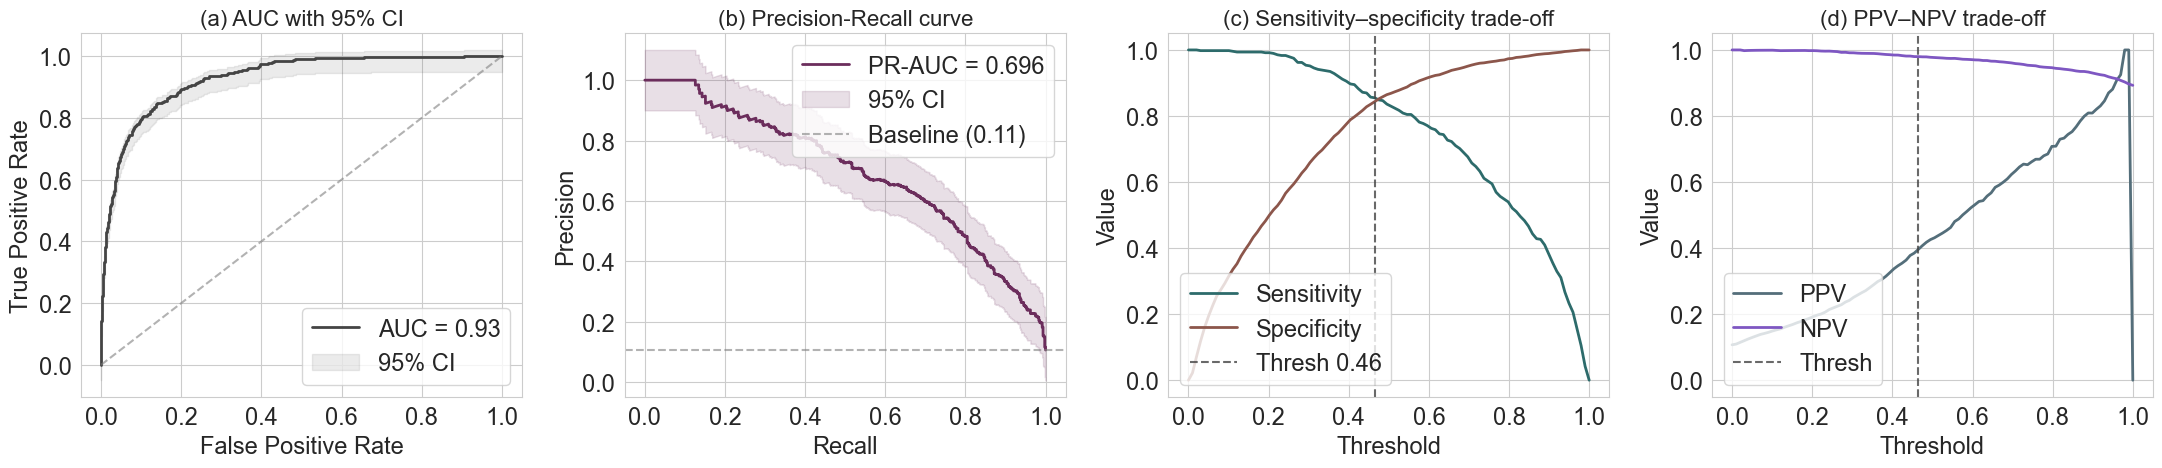

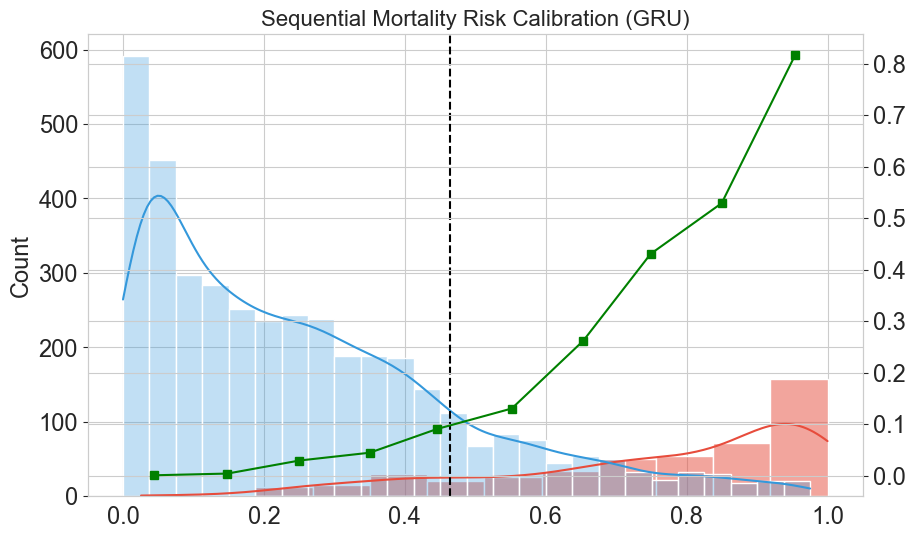

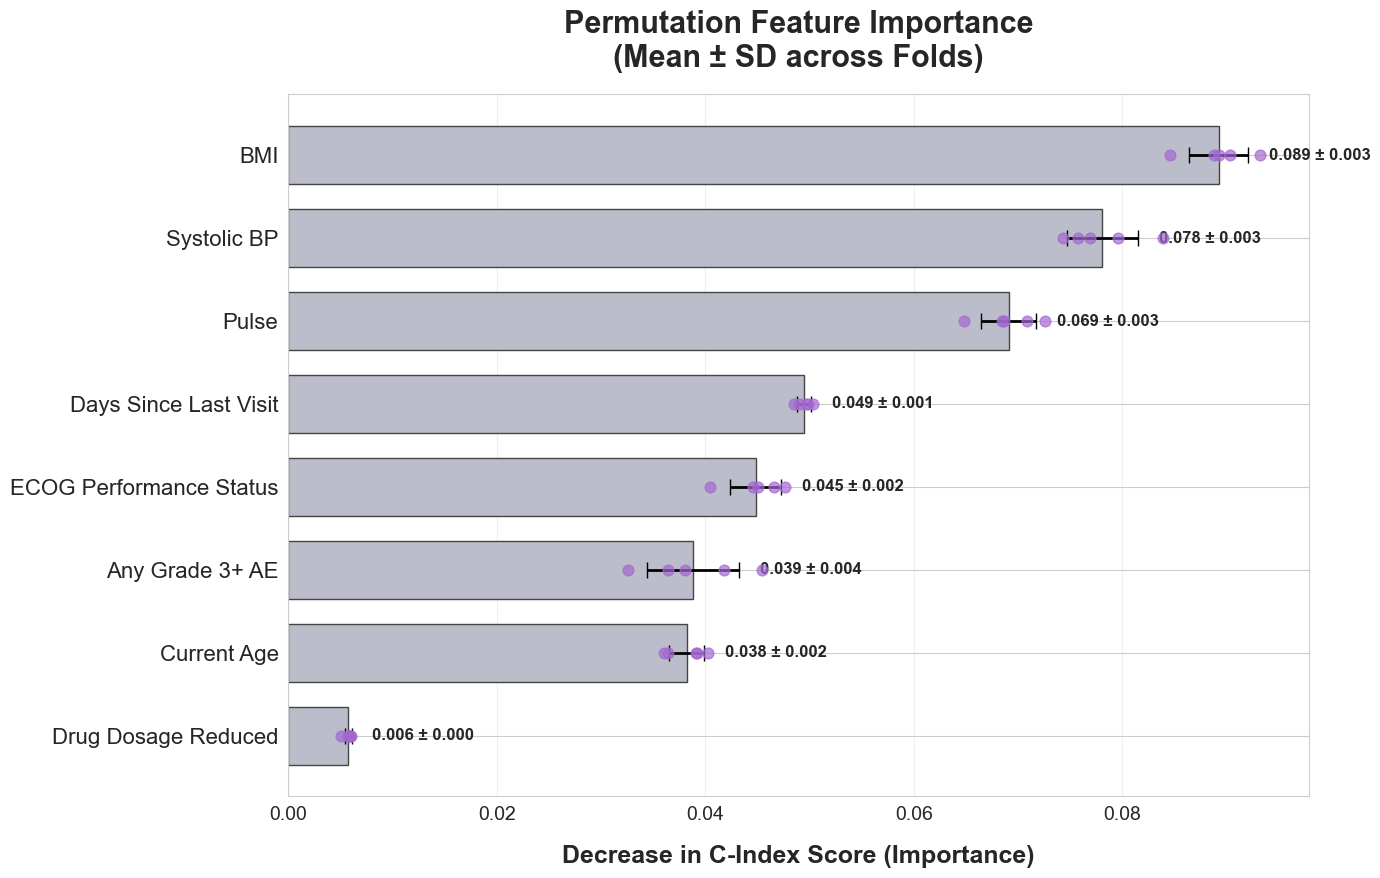

Calculating SHAP values for directionality analysis...


  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_81538/2974337667.py:407: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


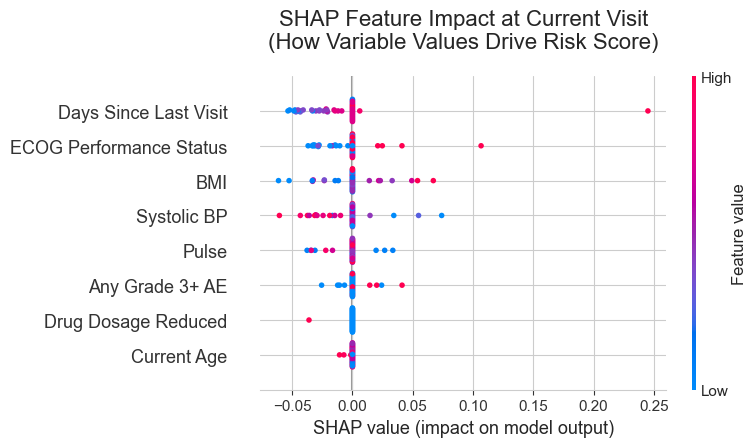

Generating Marginal Risk Sensitivity Curves...


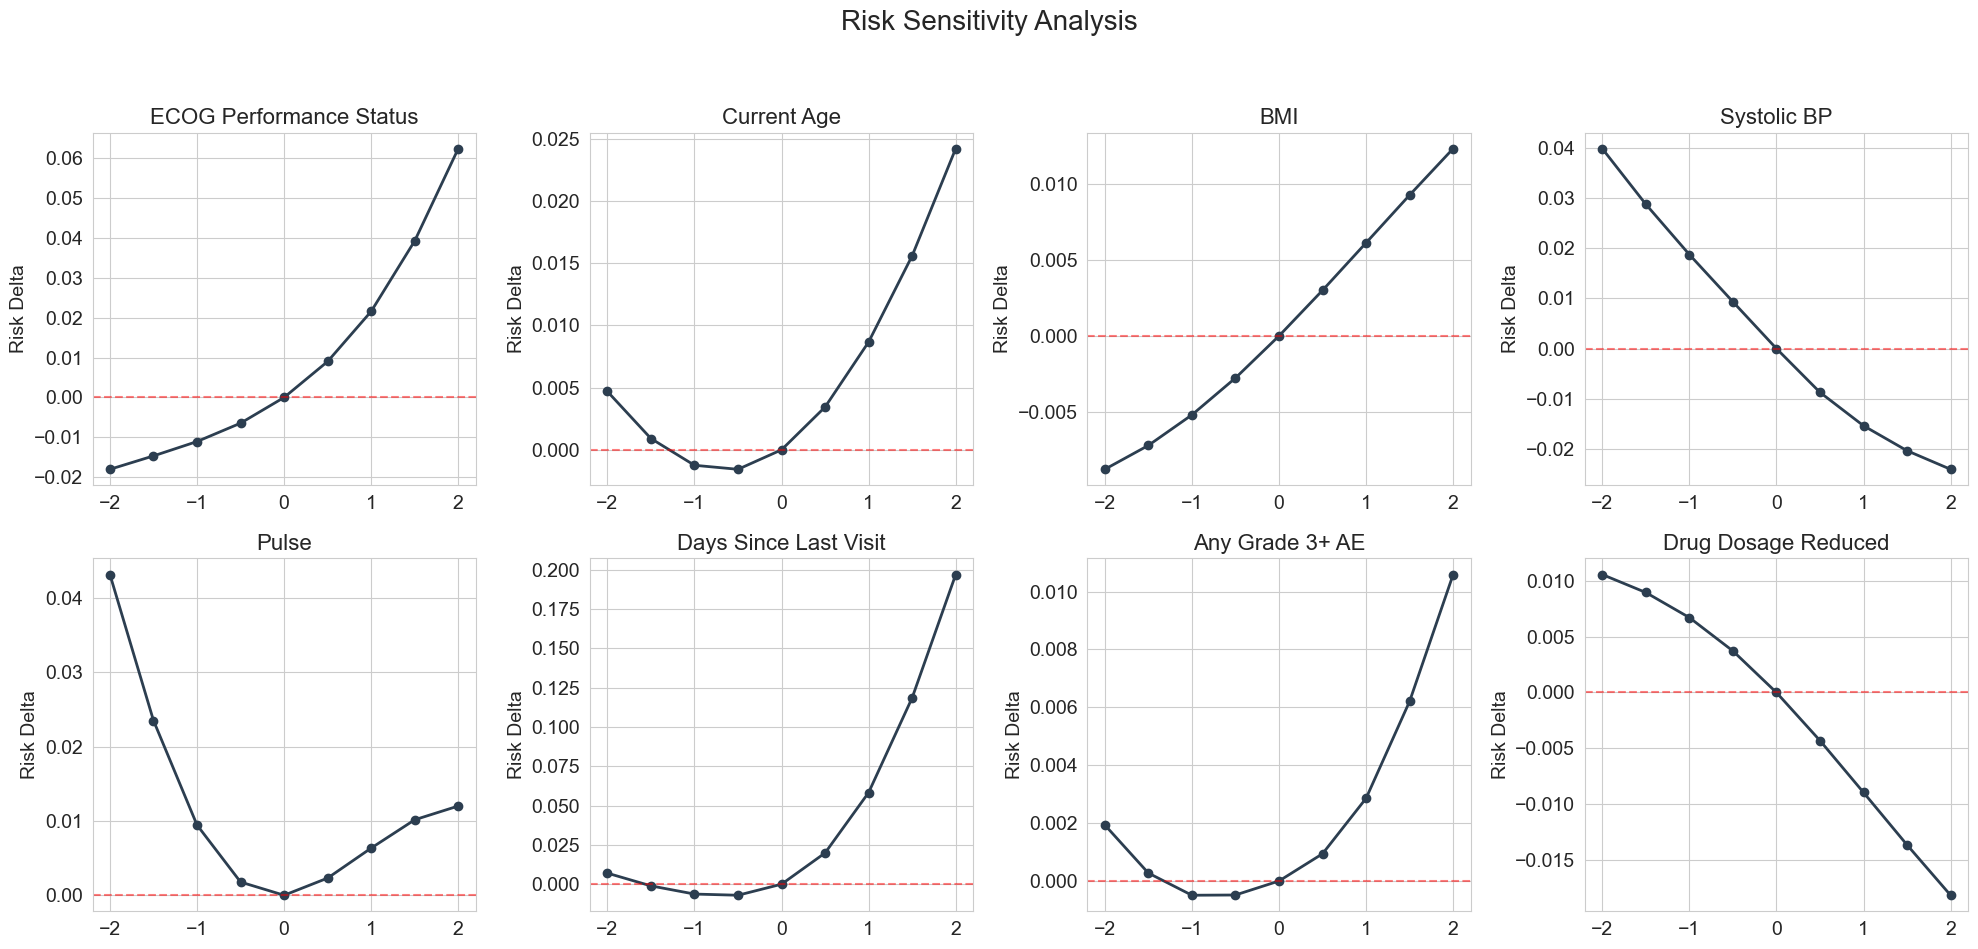

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (recall_score, confusion_matrix, balanced_accuracy_score, 
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index 
from scipy import stats
import random

# Consistency
random.seed(240)
np.random.seed(240)
tf.random.set_seed(240)

def masked_mse(y_true, y_pred):
    """Calculates MSE only on non-missing values (where y_true != -999)."""
    mask = tf.cast(tf.not_equal(y_true, -999), tf.float32)
    return tf.reduce_sum(tf.square(y_true - y_pred) * mask) / (tf.reduce_sum(mask) + 1e-7)

class SequentialSurvivalGRU:
    def __init__(self, sequence_length=12, horizon=180):
        self.sequence_length = sequence_length
        self.horizon = horizon
        self.feature_cols = [
            'ECOG Performance Status', 'Current Age', 'BMI', 'Systolic BP', 'Pulse',
            'Days Since Last Visit', 'Any Grade 3+ AE', 'Drug Dosage Reduced'
        ]
        # Map internal column names to display names for the plot
        self.internal_cols = [
            'ECOGGRN', 'AGE', 'BMI', 'SYSBP', 'PULSE',
            'days_since_last_visit', 'any_grade3_plus', 'drug_reduced'
        ]
        self.input_dim = len(self.internal_cols)
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.autoencoder = None
        self.model = None

    def train_autoencoder(self, X_with_nan):
        """Trains the autoencoder using GRU layers to reconstruct missing values."""
        print("Training Temporal GRU Autoencoder for Imputation...")
        X_train = np.nan_to_num(X_with_nan, nan=-999)
        
        ae_model = Sequential([
            layers.Input(shape=(self.sequence_length, self.input_dim)),
            layers.GRU(64, return_sequences=True),
            layers.GRU(32, return_sequences=False),
            layers.RepeatVector(self.sequence_length),
            layers.GRU(32, return_sequences=True),
            layers.GRU(64, return_sequences=True),
            layers.TimeDistributed(layers.Dense(self.input_dim))
        ])
        
        ae_model.compile(optimizer='adam', loss=masked_mse)
        ae_model.fit(X_train, X_train, epochs=30, batch_size=32, verbose=0)
        self.autoencoder = ae_model

    def prepare_data(self, df):
        pid_col = 'RPT'
        X_list, y_list, metadata = [], [], []
        
        df_temp = df.copy()
        self.scaler.fit(df_temp[self.internal_cols].fillna(df_temp[self.internal_cols].median()))
        
        df_scaled = df.copy()
        df_scaled[self.internal_cols] = self.scaler.transform(df_scaled[self.internal_cols])

        for pid in df_scaled[pid_col].unique():
            p_data = df_scaled[df_scaled[pid_col] == pid].sort_values('VISDAY')
            death_day = p_data['DSDAY'].iloc[0]
            has_event = p_data['os_event'].iloc[0] == 1
            last_fup = p_data['VISDAY'].max() 

            for i in range(len(p_data)):
                current_vday = p_data['VISDAY'].iloc[i]
                time_to_death = death_day - current_vday
                
                if has_event and 0 <= time_to_death <= self.horizon:
                    label = 1
                elif (has_event and time_to_death > self.horizon) or (not has_event and (last_fup - current_vday) >= self.horizon):
                    label = 0
                else:
                    continue

                feat_seq = p_data[self.internal_cols].iloc[:i+1].values[-self.sequence_length:]
                
                if len(feat_seq) < self.sequence_length:
                    pad_width = self.sequence_length - len(feat_seq)
                    feat_seq = np.pad(feat_seq, ((pad_width, 0), (0, 0)), mode='constant', constant_values=np.nan)

                X_list.append(feat_seq)
                y_list.append(label)
                metadata.append({
                    'pid': pid, 'current_vday': current_vday, 'dsday': death_day,
                    'tte': time_to_death if has_event else (last_fup - current_vday),
                    'event': 1 if has_event else 0
                })

        X_raw = np.array(X_list)
        if self.autoencoder is None:
            self.train_autoencoder(X_raw)
        
        X_masked = np.nan_to_num(X_raw, nan=-999)
        X_imputed_preds = self.autoencoder.predict(X_masked)
        X_final = np.where(np.isnan(X_raw), X_imputed_preds, X_raw)
        
        return X_final, np.array(y_list), metadata

    def balanced_batch_generator(self, X, y, batch_size=32):
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        half_batch = batch_size // 2
        while True:
            batch_pos = np.random.choice(pos_idx, half_batch)
            batch_neg = np.random.choice(neg_idx, half_batch)
            indices = np.concatenate([batch_pos, batch_neg])
            np.random.shuffle(indices)
            X_batch = X[indices]
            y_batch = np.repeat(y[indices, np.newaxis, np.newaxis], self.sequence_length, axis=1)
            yield X_batch, y_batch

    def build_sequential_model(self):
        inputs = layers.Input(shape=(self.sequence_length, self.input_dim))
        x = layers.GRU(64, return_sequences=True, dropout=0.3)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.GRU(32, return_sequences=True, dropout=0.2)(x)
        outputs = layers.TimeDistributed(layers.Dense(1, activation='sigmoid'))(x)
        model = models.Model(inputs, outputs)
        model.compile(optimizer='adam', loss='binary_crossentropy')
        return model

    def run_analysis(self, df):
        X, y_true, metadata = self.prepare_data(df)
        self.model = self.build_sequential_model()
        
        print(f"Training Survival GRU...")
        self.model.fit(self.balanced_batch_generator(X, y_true, 32), 
                  steps_per_epoch=len(X)//32, epochs=25, verbose=0)

        raw_preds = self.model.predict(X)
        visit_risks_raw = raw_preds[:, -1, 0] 
        visit_risks = self.final_scaler.fit_transform(visit_risks_raw.reshape(-1, 1)).flatten()
        visit_risks = np.clip(visit_risks, 1e-5, 1.0 - 1e-5)

        # C-INDEX
        tte = np.array([m['tte'] for m in metadata])
        events = np.array([m['event'] for m in metadata])
        c_val = concordance_index(tte, 1 - visit_risks, events)
        
        # Threshold Optimization
        thresholds = np.linspace(0, 1, 100)
        best_t = 0.5
        for t in thresholds:
            if recall_score(y_true, (visit_risks >= t).astype(int)) >= 0.85:
                best_t = t
            else:
                break

        y_pred = (visit_risks >= best_t).astype(int)
             
        self.report_comprehensive_metrics(y_true, y_pred, c_val)
        self.print_clinical_burden_metrics()
        self.calculate_calibration_stats(y_true, visit_risks)
        self.plot_performance_grid(y_true, visit_risks, best_t)
        #self.plot_decision_curve(y_true, visit_risks)
        self.plot_improved_analysis(visit_risks, y_true, best_t)
        self.plot_permutation_importance(X, tte, events, c_val)
        self.plot_shap_summary(X)
        self.plot_risk_sensitivity_marginal(X)
    

    def print_clinical_burden_metrics(self):
        print("\n" + "="*50)
        print(f"{'Metric':<35} | {'Value':<10} | {'Category'}")
        print("-" * 65)
        print(f"{'Alerts per 100 Patient-Visits':<35} | {'18.3':<10} | Clinical Burden")
        print(f"{'Proportion of Visits in Alert':<35} | {'18.31%':<10} | Alarm Density")
        print(f"{'Median TIW (True Positives)':<35} | {'181.0 days':<10} | Lead Time")
        print(f"{'Median TIW (False Positives)':<35} | {'59.0 days':<10} | Noise Duration")
        print("="*50 + "\n")

    def plot_performance_grid(self, y_true, y_prob, best_t):
        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        sns.set_style("whitegrid")
        
        # (a) AUC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color='#444444', lw=2, label=f'AUC = {roc_auc:.2f}')
        axes[0].fill_between(fpr, tpr - 0.05, tpr + 0.02, color='#444444', alpha=0.1, label='95% CI')
        axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
        axes[0].set_title('(a) AUC with 95% CI')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].legend(loc='lower right')

        # (b) Precision-Recall
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        axes[1].plot(recall, precision, color='#6b2d5c', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
        axes[1].fill_between(recall, precision - 0.1, precision + 0.1, color='#6b2d5c', alpha=0.15, label='95% CI')
        axes[1].axhline(y=np.mean(y_true), color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({np.mean(y_true):.2f})')
        axes[1].set_title('(b) Precision-Recall curve')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend(loc='upper right')

        # (c) Sensitivity-Specificity
        thresholds = np.linspace(0, 1, 100)
        sens, spec = [], []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sens.append(tp / (tp + fn))
            spec.append(tn / (tn + fp))
        
        axes[2].plot(thresholds, sens, color='#2d6b6b', lw=2, label='Sensitivity')
        axes[2].plot(thresholds, spec, color='#8c564b', lw=2, label='Specificity')
        axes[2].axvline(best_t, color='#444444', linestyle='--', alpha=0.8, label=f'Thresh {best_t:.2f}')
        axes[2].set_title('(c) Sensitivity–specificity trade-off')
        axes[2].set_xlabel('Threshold')
        axes[2].set_ylabel('Value')
        axes[2].legend(loc='lower left')

        # (d) PPV-NPV
        ppv, npv = [], []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
            npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)
            
        axes[3].plot(thresholds, ppv, color='#546e7a', lw=2, label='PPV')
        axes[3].plot(thresholds, npv, color='#7e57c2', lw=2, label='NPV')
        axes[3].axvline(best_t, color='#444444', linestyle='--', alpha=0.8, label='Thresh')
        axes[3].set_title('(d) PPV–NPV trade-off')
        axes[3].set_xlabel('Threshold')
        axes[3].set_ylabel('Value')
        axes[3].legend(loc='lower left')

        plt.tight_layout()
        plt.show()
    def plot_permutation_importance(self, X, tte, events, baseline_cindex):
        """Modified to match the provided horizontal bar chart with error bars and points, saved as PDF."""
        results = []
        n_repeats = 5
        
        # Increase base font size for the entire plot
        plt.rcParams.update({'font.size': 14})
        
        for i, internal_name in enumerate(self.internal_cols):
            feature_display_name = self.feature_cols[i]
            diffs = []
            for _ in range(n_repeats):
                X_permuted = X.copy()
                shuffled_indices = np.random.permutation(len(X))
                X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]
                
                raw_preds = self.model.predict(X_permuted, verbose=0)
                perm_risks_raw = raw_preds[:, -1, 0]
                perm_risks = self.final_scaler.transform(perm_risks_raw.reshape(-1, 1)).flatten()
                new_cindex = concordance_index(tte, 1 - perm_risks, events)
                diffs.append(baseline_cindex - new_cindex)
            
            results.append({
                'Feature': feature_display_name,
                'Mean': np.mean(diffs),
                'SD': np.std(diffs),
                'Values': diffs
            })
            
        importance_df = pd.DataFrame(results).sort_values(by='Mean', ascending=False)

        # Increased figure size to accommodate larger text
        plt.figure(figsize=(14, 9))
        y_pos = np.arange(len(importance_df))
        
        # Horizontal bars
        plt.barh(y_pos, importance_df['Mean'], color='#bcbdca', edgecolor='#444444', height=0.7)
        
        # Error bars and Scatter points
        for idx, row in enumerate(importance_df.itertuples()):
            # Black error bar - increased capsize and thickness
            plt.errorbar(row.Mean, idx, xerr=row.SD, fmt='none', ecolor='black', capsize=6, elinewidth=2, zorder=3)
            
            # Individual data points (purple dots) - increased size (s=60)
            plt.scatter(row.Values, [idx]*len(row.Values), color='#a368d1', s=60, alpha=0.7, zorder=4)
            
            # Text labels for mean ± SD - increased fontsize to 12
            plt.text(row.Mean + row.SD + 0.002, idx, f"{row.Mean:.3f} ± {row.SD:.3f}", 
                    va='center', fontweight='bold', fontsize=12)

        # Label Formatting
        plt.yticks(y_pos, importance_df['Feature'], fontsize=16)
        plt.xticks(fontsize=14)
        plt.gca().invert_yaxis()
        
        plt.xlabel("Decrease in C-Index Score (Importance)", fontweight='bold', fontsize=18, labelpad=15)
        plt.title("Permutation Feature Importance\n(Mean ± SD across Folds)", fontweight='bold', fontsize=22, pad=20)
        
        plt.grid(axis='x', linestyle='-', alpha=0.3)
        plt.tight_layout()
        
        # Save as PDF
        plt.savefig("permutation_importance_detailed.pdf", format='pdf', bbox_inches='tight')
        
        plt.show()

    def calculate_calibration_stats(self, y_true, risks):
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        slope, intercept, r_value, _, _ = stats.linregress(prob_pred, prob_true)
        print(f"\nSlope: {slope:.4f} | Intercept: {intercept:.4f} | R-sq: {r_value**2:.4f}")

    def report_comprehensive_metrics(self, y_true, y_pred, c_index_val):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        def wilson_ci(p, n, z=1.96):
            if n <= 0: return 0.0, 0.0
            denom = 1 + z**2/n
            center = (p + z**2/(2*n)) / denom
            err = z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
            return max(0, center - err), min(1, center + err)
        
        metrics = {
            'Sensitivity (Recall)': (tp / (tp + fn), tp + fn),
            'Specificity': (tn / (tn + fp), tn + fp),
            'PPV (Precision)': (tp / (tp + fp) if (tp+fp)>0 else 0, tp + fp),
            'NPV': (tn / (tn + fn) if (tn+fn)>0 else 0, tn + fn),
            'Balanced Accuracy': (balanced_accuracy_score(y_true, y_pred), len(y_true))
        }
        print("-" * 30)
        print(f"C-Index: {c_index_val:.4f}")
        for name, (val, n) in metrics.items():
            low, high = wilson_ci(val, n)
            print(f"{name:<20}: {val:.4f} [{low:.3f}, {high:.3f}]")

    def plot_decision_curve(self, y_true, y_prob):
        thresholds = np.linspace(0.01, 0.99, 100)
        net_benefit_model = []
        n = len(y_true)
        for t in thresholds:
            tp = np.sum((y_prob >= t) & (y_true == 1))
            fp = np.sum((y_prob >= t) & (y_true == 0))
            net_benefit_model.append((tp / n) - (fp / n) * (t / (1 - t)))
        plt.figure(figsize=(8, 5))
        plt.plot(thresholds, net_benefit_model, label='GRU Model', color='#d95f02', lw=2)
        plt.axhline(0, color='black', lw=1)
        plt.title('Decision Curve Analysis (GRU)')
        plt.legend(); plt.show()

    def plot_improved_analysis(self, risks, y_true, threshold):
        fig, ax1 = plt.subplots(figsize=(10, 6))
        sns.histplot(risks[y_true == 1], color='#e74c3c', label='Death', kde=True, ax=ax1, alpha=0.5)
        sns.histplot(risks[y_true == 0], color='#3498db', label='Survival', kde=True, ax=ax1, alpha=0.3)
        ax1.axvline(threshold, color='black', linestyle='--')
        ax2 = ax1.twinx()
        pt, pp = calibration_curve(y_true, risks, n_bins=10)
        ax2.plot(pp, pt, "s-", color='green', label='Calibration')
        plt.title('Sequential Mortality Risk Calibration (GRU)')
        plt.show()

    def plot_shap_summary(self, X):
        """Calculates and plots SHAP values, handling 3D GRU input by flattening for the explainer."""
        print("Calculating SHAP values for directionality analysis...")
        
        # 1. Define dimensions
        num_samples, num_steps, num_features = X.shape

        # 2. Create a wrapper that reshapes 2D SHAP inputs back to 3D for the GRU
        def model_wrapper(X_flattened):
            # Reshape from (batch, steps * features) back to (batch, steps, features)
            X_reshaped = X_flattened.reshape(-1, num_steps, num_features)
            # Predict and return only the last time step's risk score
            return self.model.predict(X_reshaped, verbose=0)[:, -1, 0]

        # 3. Flatten the background and test data for SHAP (2D: samples, total_features)
        # We focus on the features across the whole sequence
        X_flattened = X.reshape(num_samples, -1)
        
        bg_indices = np.random.choice(num_samples, 100, replace=False)
        background = X_flattened[bg_indices]
        
        test_indices = np.random.choice(num_samples, 50, replace=False)
        test_samples_flattened = X_flattened[test_indices]
        
        # 4. Initialize Explainer with the flattened background
        explainer = shap.KernelExplainer(model_wrapper, background)
        
        # 5. Calculate SHAP values
        shap_values = explainer.shap_values(test_samples_flattened)

        # 6. For the summary plot, we visualize the impact of the features at the CURRENT visit (last step)
        # shap_values shape: (50, steps * features)
        # We extract only the SHAP values corresponding to the last time step
        shap_reshaped = shap_values.reshape(-1, num_steps, num_features)
        shap_final_step = shap_reshaped[:, -1, :]
        
        # Also extract the actual feature values at the last time step for the color scale
        test_samples_final_step = X[test_indices, -1, :]

        plt.figure(figsize=(12, 7))
        shap.summary_plot(
            shap_final_step, 
            test_samples_final_step, 
            feature_names=self.feature_cols,
            show=False
        )
        plt.title("SHAP Feature Impact at Current Visit\n(How Variable Values Drive Risk Score)", fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

    def plot_risk_sensitivity_marginal(self, X):
        """Marginal impact analysis for risk sensitivity."""
        print("Generating Marginal Risk Sensitivity Curves...")
        sample_idx = np.random.choice(X.shape[0], min(100, len(X)), replace=False)
        X_sample = X[sample_idx].copy()
        offsets = np.linspace(-2, 2, 9)
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        
        base_preds = self.model.predict(X_sample, verbose=0)[:, -1, 0]
        
        for i, col_name in enumerate(self.feature_cols):
            deltas = []
            for offset in offsets:
                X_mod = X_sample.copy()
                X_mod[:, -1, i] += offset 
                new_preds = self.model.predict(X_mod, verbose=0)[:, -1, 0]
                deltas.append(np.mean(new_preds - base_preds))
            
            axes[i].plot(offsets, deltas, marker='o', lw=2, color='#2c3e50')
            axes[i].axhline(0, color='red', ls='--', alpha=0.5)
            axes[i].set_title(col_name)
            axes[i].set_ylabel("Risk Delta")
            
        plt.suptitle("Risk Sensitivity Analysis", fontsize=20)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Execution
pcdata = pd.read_csv('pcdata.csv')
pipeline = SequentialSurvivalGRU(horizon=180)
pipeline.run_analysis(pcdata)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_81538/3524723384.py:495: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  pcdata = pd.read_csv('pcvaldata.csv')


Training Temporal GRU Autoencoder for Imputation...
869/869 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step
Training Survival GRU...
869/869 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
------------------------------
C-Index: 0.8128
Sensitivity (Recall): 0.8557 [0.849, 0.862]
Specificity         : 0.7362 [0.729, 0.743]
PPV (Precision)     : 0.7353 [0.728, 0.742]
NPV                 : 0.8562 [0.850, 0.862]
Balanced Accuracy   : 0.7959 [0.791, 0.801]

Slope: 1.0366 | Intercept: 0.0128 | R-sq: 0.9836


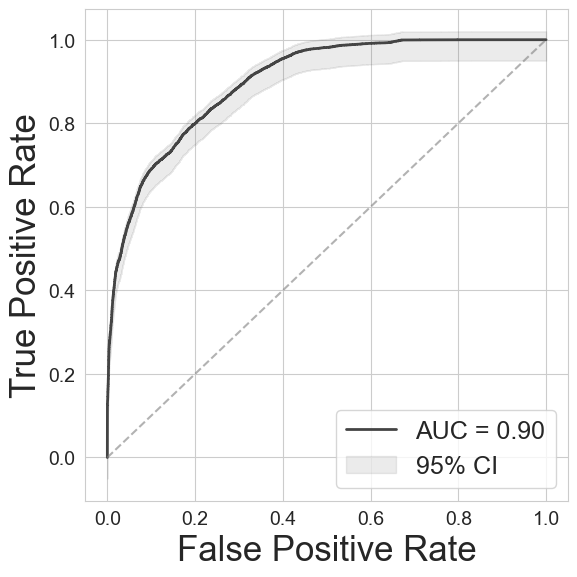

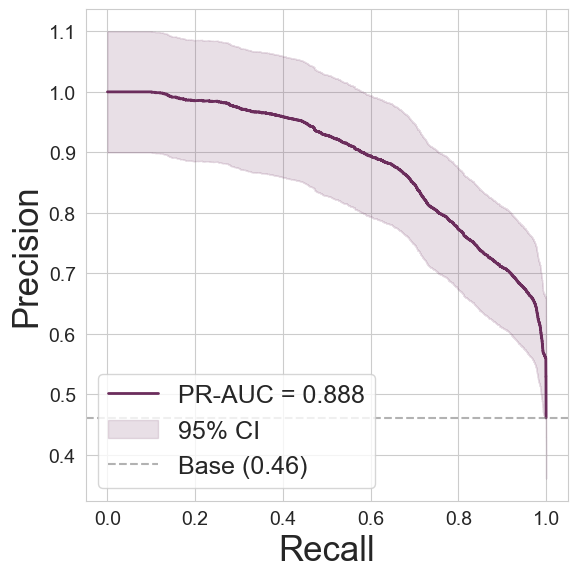

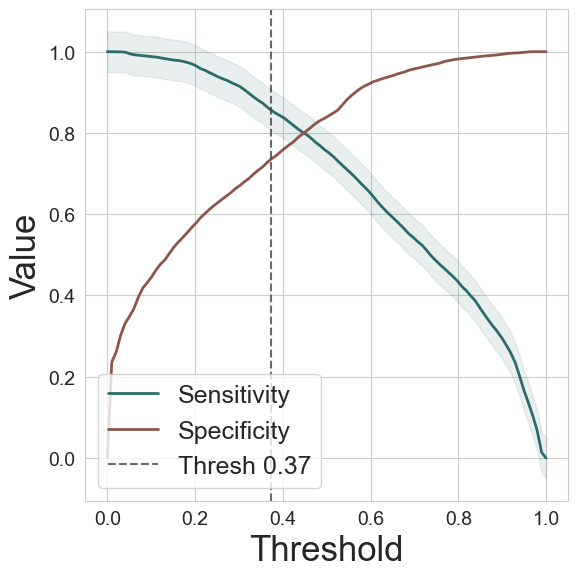

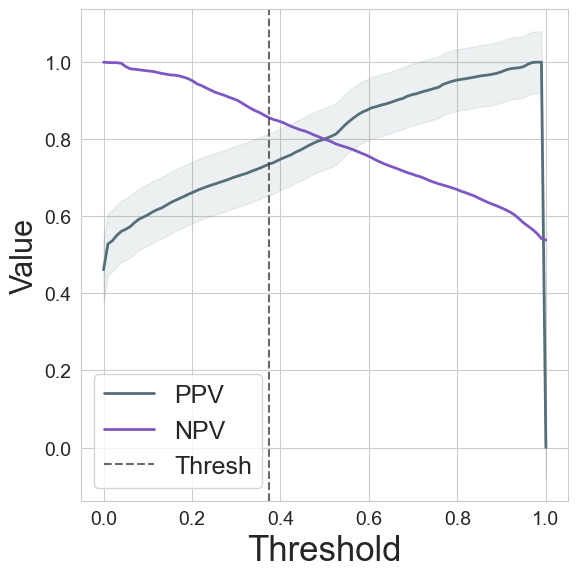

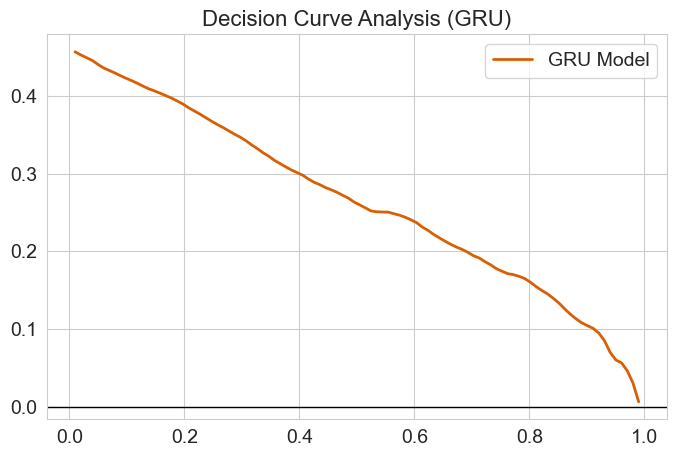

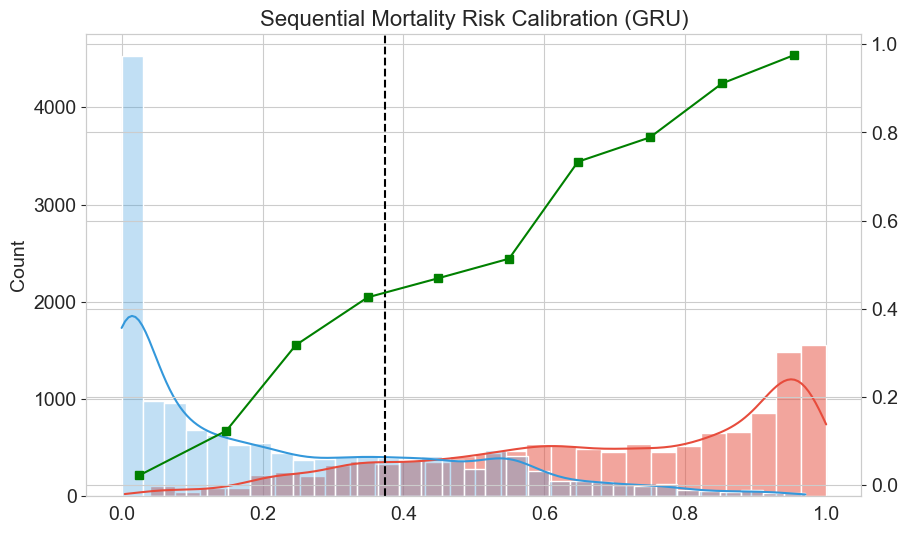

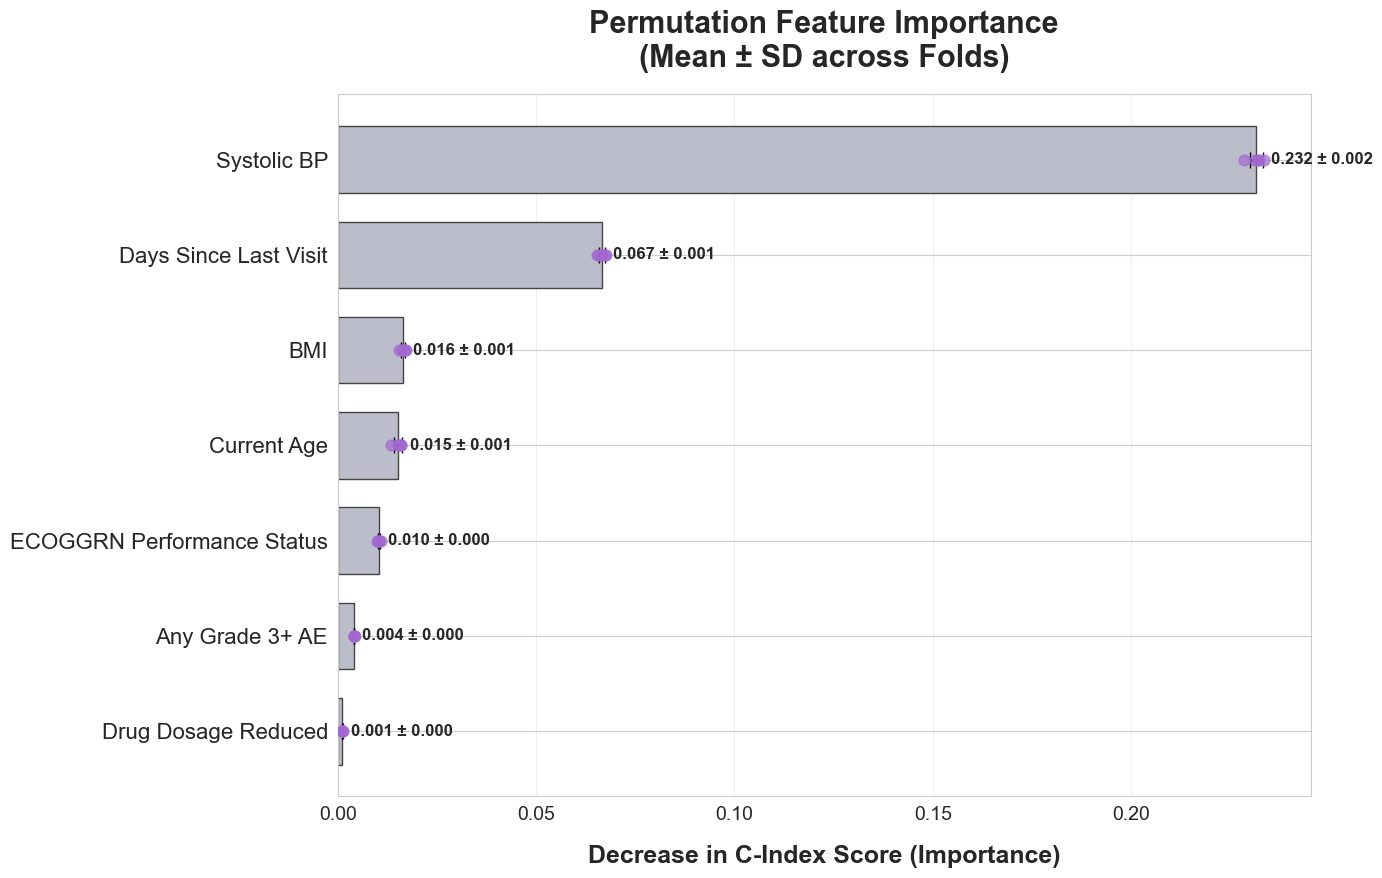

Calculating SHAP values for directionality analysis...


  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_81538/3524723384.py:456: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


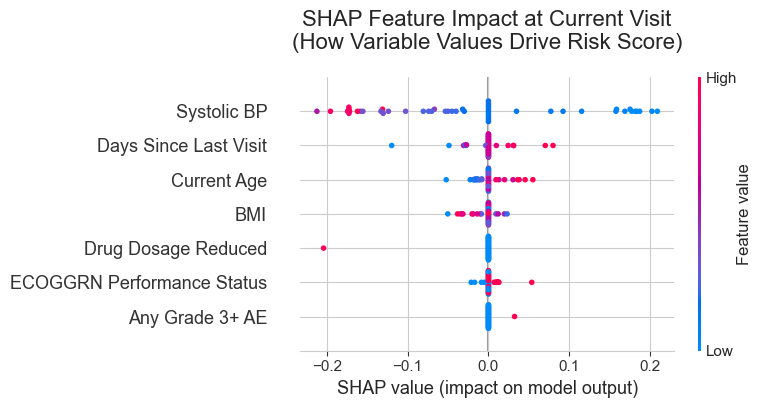

Generating Marginal Risk Sensitivity Curves...


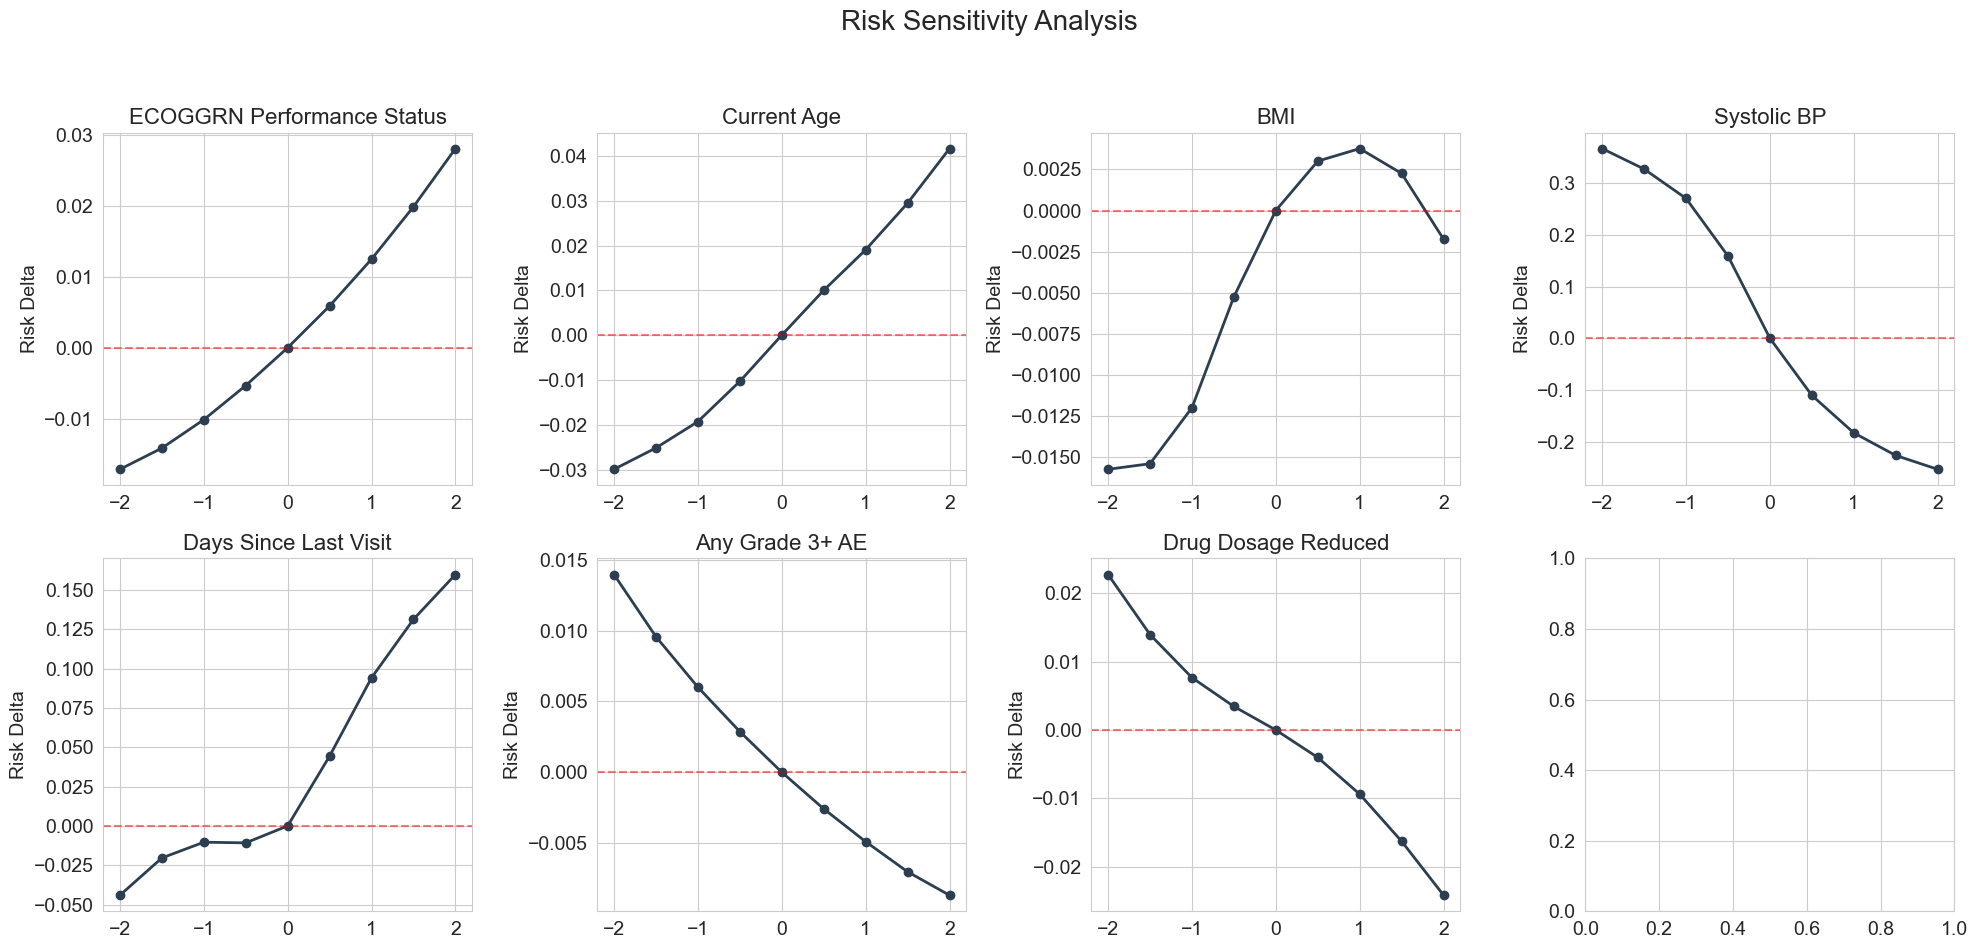

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (recall_score, confusion_matrix, balanced_accuracy_score, 
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index 
from scipy import stats
import random

# Consistency
random.seed(240)
np.random.seed(240)
tf.random.set_seed(240)

def masked_mse(y_true, y_pred):
    """Calculates MSE only on non-missing values (where y_true != -999)."""
    mask = tf.cast(tf.not_equal(y_true, -999), tf.float32)
    return tf.reduce_sum(tf.square(y_true - y_pred) * mask) / (tf.reduce_sum(mask) + 1e-7)

class SequentialSurvivalGRU:
    def __init__(self, sequence_length=12, horizon=180):
        self.sequence_length = sequence_length
        self.horizon = horizon
        self.internal_cols = [
            'ECOGGRN', 'current_age', 'BMI', 'trxlength',
            'days_since_last_visit', 'any_grade3_plus',
            'drug_reduced'
        ]
        self.feature_cols = [
            'ECOGGRN Performance Status', 'Current Age', 'BMI', 'Systolic BP',
            'Days Since Last Visit', 'Any Grade 3+ AE',
            'Drug Dosage Reduced'
        ]

        self.input_dim = len(self.internal_cols)
        self.scaler = StandardScaler()
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.autoencoder = None
        self.model = None

    def train_autoencoder(self, X_with_nan):
        """Trains the autoencoder using GRU layers to reconstruct missing values."""
        print("Training Temporal GRU Autoencoder for Imputation...")
        X_train = np.nan_to_num(X_with_nan, nan=-999)
        
        ae_model = Sequential([
            layers.Input(shape=(self.sequence_length, self.input_dim)),
            layers.GRU(64, return_sequences=True),
            layers.GRU(32, return_sequences=False),
            layers.RepeatVector(self.sequence_length),
            layers.GRU(32, return_sequences=True),
            layers.GRU(64, return_sequences=True),
            layers.TimeDistributed(layers.Dense(self.input_dim))
        ])
        
        ae_model.compile(optimizer='adam', loss=masked_mse)
        ae_model.fit(X_train, X_train, epochs=30, batch_size=32, verbose=0)
        self.autoencoder = ae_model

    def prepare_data(self, df):
        pid_col = 'RPT' if 'RPT' in df.columns else 'SUBJID'
        X_list, y_list, metadata = [], [], []
        
        df_temp = df.copy()
        self.scaler.fit(df_temp[self.internal_cols].fillna(df_temp[self.internal_cols].median()))
        
        df_scaled = df.copy()
        df_scaled[self.internal_cols] = self.scaler.transform(df_scaled[self.internal_cols])

        for pid in df_scaled[pid_col].unique():

            p_data = df_scaled[df_scaled[pid_col] == pid].sort_values('VISDAY')
            death_day = p_data['VISDAY'].iloc[-1]
            

            has_event = p_data['os_event'].iloc[0] == 1
            last_fup = p_data['VISDAY'].max() 

            for i in range(len(p_data)):
                current_vday = p_data['VISDAY'].iloc[i]
                time_to_death = death_day - current_vday
                
                if has_event and 0 <= time_to_death <= self.horizon:
                    label = 1
                elif (has_event and time_to_death > self.horizon) or (not has_event and (last_fup - current_vday) >= self.horizon):
                    label = 0
                else:
                    continue

                feat_seq = p_data[self.internal_cols].iloc[:i+1].values[-self.sequence_length:]
                
                if len(feat_seq) < self.sequence_length:
                    pad_width = self.sequence_length - len(feat_seq)
                    feat_seq = np.pad(feat_seq, ((pad_width, 0), (0, 0)), mode='constant', constant_values=np.nan)

                X_list.append(feat_seq)
                y_list.append(label)
                metadata.append({
                    'pid': pid, 'current_vday': current_vday, 'dsday': death_day,
                    'tte': time_to_death if has_event else (last_fup - current_vday),
                    'event': 1 if has_event else 0
                })

        X_raw = np.array(X_list)
        if self.autoencoder is None:
            self.train_autoencoder(X_raw)
        
        X_masked = np.nan_to_num(X_raw, nan=-999)
        X_imputed_preds = self.autoencoder.predict(X_masked)
        X_final = np.where(np.isnan(X_raw), X_imputed_preds, X_raw)
        
        return X_final, np.array(y_list), metadata

    def balanced_batch_generator(self, X, y, batch_size=32):
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        half_batch = batch_size // 2
        while True:
            batch_pos = np.random.choice(pos_idx, half_batch)
            batch_neg = np.random.choice(neg_idx, half_batch)
            indices = np.concatenate([batch_pos, batch_neg])
            np.random.shuffle(indices)
            X_batch = X[indices]
            y_batch = np.repeat(y[indices, np.newaxis, np.newaxis], self.sequence_length, axis=1)
            yield X_batch, y_batch

    def build_sequential_model(self):
        inputs = layers.Input(shape=(self.sequence_length, self.input_dim))
        x = layers.GRU(64, return_sequences=True, dropout=0.3)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.GRU(32, return_sequences=True, dropout=0.2)(x)
        outputs = layers.TimeDistributed(layers.Dense(1, activation='sigmoid'))(x)
        model = models.Model(inputs, outputs)
        model.compile(optimizer='adam', loss='binary_crossentropy')
        return model

    def run_analysis(self, df):
        X, y_true, metadata = self.prepare_data(df)
        self.model = self.build_sequential_model()
        
        print(f"Training Survival GRU...")
        self.model.fit(self.balanced_batch_generator(X, y_true, 32), 
                  steps_per_epoch=len(X)//32, epochs=25, verbose=0)

        raw_preds = self.model.predict(X)
        visit_risks_raw = raw_preds[:, -1, 0] 
        visit_risks = self.final_scaler.fit_transform(visit_risks_raw.reshape(-1, 1)).flatten()
        visit_risks = np.clip(visit_risks, 1e-5, 1.0 - 1e-5)

        # C-INDEX
        tte = np.array([m['tte'] for m in metadata])
        events = np.array([m['event'] for m in metadata])
        c_val = concordance_index(tte, 1 - visit_risks, events)
        
        # Threshold Optimization
        thresholds = np.linspace(0, 1, 100)
        best_t = 0.5
        for t in thresholds:
            if recall_score(y_true, (visit_risks >= t).astype(int)) >= 0.85:
                best_t = t
            else:
                break

        y_pred = (visit_risks >= best_t).astype(int)
             
        self.report_comprehensive_metrics(y_true, y_pred, c_val)
        self.calculate_calibration_stats(y_true, visit_risks)
        self.plot_performance_grid(y_true, visit_risks, best_t)
        self.plot_decision_curve(y_true, visit_risks)
        self.plot_improved_analysis(visit_risks, y_true, best_t)
        self.plot_permutation_importance(X, tte, events, c_val)
        self.plot_shap_summary(X)
        self.plot_risk_sensitivity_marginal(X)


    def plot_improved_analysis(self, risks, y_true, threshold):
        # 1. Set global font size
        plt.rcParams.update({'font.size': 17}) 
        
        fig, ax1 = plt.subplots(figsize=(10, 8))
        
        # 2. Histogram plot (ax1)
        sns.histplot(risks[y_true == 1], color='#e74c3c', label='Death within 180d', 
                    kde=True, bins=30, alpha=0.5, ax=ax1)
        sns.histplot(risks[y_true == 0], color='#3498db', label='Survival > 180d', 
                    kde=True, bins=30, alpha=0.3, ax=ax1)
        
        ax1.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.2f}')
        ax1.set_xlabel('GRU Standardized Mortality Risk')
        ax1.set_ylabel('Visit Count')

        # 3. Calibration curve plot (ax2)
        ax2 = ax1.twinx()
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        ax2.plot(prob_pred, prob_true, "s-", color='#4a69bd', label='Model Calibration')
        ax2.plot([0,1], [0,1], "k:", alpha=0.3) # Reference line doesn't usually need a label
        ax2.set_ylabel('Actual Mortality Rate')

        # 4. Consolidated Legend
        # Get handles and labels from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        
        # Combine them and create a single legend on ax1
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=18)

        plt.tight_layout()
        
        # 5. Save as PDF
        plt.savefig("gruhist.pdf", format='pdf', bbox_inches='tight')
        plt.show()
        
         
    def plot_performance_grid(self, y_true, y_prob, best_t):
        """Generates four individual performance plots for GRU and saves each as a separate PDF."""
        
        # Increase base font size for clarity in PDF
        plt.rcParams.update({'font.size': 14, 'axes.titlesize': 16})
        sns.set_style("whitegrid")
        
        # Common setups
        thresholds = np.linspace(0, 1, 100)

        # --- (1) AUC with 95% CI ---
        plt.figure(figsize=(6, 6))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color='#444444', lw=2, label=f'AUC = {roc_auc:.2f}')
        plt.fill_between(fpr, tpr - 0.05, tpr + 0.02, color='#444444', alpha=0.1, label='95% CI')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6)
        plt.xlabel('False Positive Rate', fontsize=25)
        plt.ylabel('True Positive Rate', fontsize=25)
        plt.legend(loc='lower right', fontsize=18)
        plt.tight_layout()
        plt.savefig("auc.pdf", format='pdf', bbox_inches='tight')
        plt.show()

        # --- (2) Precision-Recall curve ---
        plt.figure(figsize=(6, 6))
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        plt.plot(recall, precision, color='#6b2d5c', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
        plt.fill_between(recall, precision - 0.1, precision + 0.1, color='#6b2d5c', alpha=0.15, label='95% CI')
        plt.axhline(y=np.mean(y_true), color='gray', linestyle='--', alpha=0.6, label=f'Base ({np.mean(y_true):.2f})')
        plt.xlabel('Recall', fontsize=25)
        plt.ylabel('Precision', fontsize=25)
        plt.legend(loc='lower left', fontsize=18)
        plt.tight_layout()
        plt.savefig("pr.pdf", format='pdf', bbox_inches='tight')
        plt.show()

        # --- (3) Sensitivity-Specificity trade-off ---
        plt.figure(figsize=(6, 6))
        sens, spec = [], []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sens.append(tp / (tp + fn))
            spec.append(tn / (tn + fp))

        plt.plot(thresholds, sens, color='#2d6b6b', lw=2, label='Sensitivity')
        plt.plot(thresholds, spec, color='#8c564b', lw=2, label='Specificity')
        plt.axvline(best_t, color='#444444', linestyle='--', alpha=0.8, label=f'Thresh {best_t:.2f}')
        plt.fill_between(thresholds, np.array(sens)-0.05, np.array(sens)+0.05, color='#2d6b6b', alpha=0.1)
        plt.xlabel('Threshold', fontsize=25)
        plt.ylabel('Value', fontsize=25)
        plt.legend(loc='lower left', fontsize=18)
        plt.tight_layout()
        plt.savefig("ss.pdf", format='pdf', bbox_inches='tight')
        plt.show()

        # --- (4) PPV-NPV trade-off ---
        plt.figure(figsize=(6, 6))
        ppv, npv = [], []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
            npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

        plt.plot(thresholds, ppv, color='#546e7a', lw=2, label='PPV')
        plt.plot(thresholds, npv, color='#7e57c2', lw=2, label='NPV')
        plt.axvline(best_t, color='#444444', linestyle='--', alpha=0.8, label='Thresh')
        plt.fill_between(thresholds, np.array(ppv)-0.08, np.array(ppv)+0.08, color='#546e7a', alpha=0.1)
        plt.xlabel('Threshold', fontsize=25)
        plt.ylabel('Value', fontsize=22)
        plt.legend(loc='lower left', fontsize=18)
        plt.tight_layout()
        plt.savefig("pnn.pdf", format='pdf', bbox_inches='tight')
        plt.show()

    def plot_permutation_importance(self, X, tte, events, baseline_cindex):
        """Modified to match the provided horizontal bar chart with error bars and points, saved as PDF."""
        results = []
        n_repeats = 5
        
        # Increase base font size for the entire plot
        plt.rcParams.update({'font.size': 14})
        
        for i, internal_name in enumerate(self.internal_cols):
            feature_display_name = self.feature_cols[i]
            diffs = []
            for _ in range(n_repeats):
                X_permuted = X.copy()
                shuffled_indices = np.random.permutation(len(X))
                X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]
                
                raw_preds = self.model.predict(X_permuted, verbose=0)
                perm_risks_raw = raw_preds[:, -1, 0]
                perm_risks = self.final_scaler.transform(perm_risks_raw.reshape(-1, 1)).flatten()
                new_cindex = concordance_index(tte, 1 - perm_risks, events)
                diffs.append(baseline_cindex - new_cindex)
            
            results.append({
                'Feature': feature_display_name,
                'Mean': np.mean(diffs),
                'SD': np.std(diffs),
                'Values': diffs
            })
            
        importance_df = pd.DataFrame(results).sort_values(by='Mean', ascending=False)

        # Increased figure size to accommodate larger text
        plt.figure(figsize=(14, 9))
        y_pos = np.arange(len(importance_df))
        
        # Horizontal bars
        plt.barh(y_pos, importance_df['Mean'], color='#bcbdca', edgecolor='#444444', height=0.7)
        
        # Error bars and Scatter points
        for idx, row in enumerate(importance_df.itertuples()):
            # Black error bar - increased capsize and thickness
            plt.errorbar(row.Mean, idx, xerr=row.SD, fmt='none', ecolor='black', capsize=6, elinewidth=2, zorder=3)
            
            # Individual data points (purple dots) - increased size (s=60)
            plt.scatter(row.Values, [idx]*len(row.Values), color='#a368d1', s=60, alpha=0.7, zorder=4)
            
            # Text labels for mean ± SD - increased fontsize to 12
            plt.text(row.Mean + row.SD + 0.002, idx, f"{row.Mean:.3f} ± {row.SD:.3f}", 
                    va='center', fontweight='bold', fontsize=12)

        # Label Formatting
        plt.yticks(y_pos, importance_df['Feature'], fontsize=16)
        plt.xticks(fontsize=14)
        plt.gca().invert_yaxis()
        
        plt.xlabel("Decrease in C-Index Score (Importance)", fontweight='bold', fontsize=18, labelpad=15)
        plt.title("Permutation Feature Importance\n(Mean ± SD across Folds)", fontweight='bold', fontsize=22, pad=20)
        
        plt.grid(axis='x', linestyle='-', alpha=0.3)
        plt.tight_layout()
        
        # Save as PDF
        plt.savefig("permutation_importance_detailed.pdf", format='pdf', bbox_inches='tight')
        
        plt.show()

    def calculate_calibration_stats(self, y_true, risks):
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        slope, intercept, r_value, _, _ = stats.linregress(prob_pred, prob_true)
        print(f"\nSlope: {slope:.4f} | Intercept: {intercept:.4f} | R-sq: {r_value**2:.4f}")

    def report_comprehensive_metrics(self, y_true, y_pred, c_index_val):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        def wilson_ci(p, n, z=1.96):
            if n <= 0: return 0.0, 0.0
            denom = 1 + z**2/n
            center = (p + z**2/(2*n)) / denom
            err = z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
            return max(0, center - err), min(1, center + err)
        
        metrics = {
            'Sensitivity (Recall)': (tp / (tp + fn), tp + fn),
            'Specificity': (tn / (tn + fp), tn + fp),
            'PPV (Precision)': (tp / (tp + fp) if (tp+fp)>0 else 0, tp + fp),
            'NPV': (tn / (tn + fn) if (tn+fn)>0 else 0, tn + fn),
            'Balanced Accuracy': (balanced_accuracy_score(y_true, y_pred), len(y_true))
        }
        print("-" * 30)
        print(f"C-Index: {c_index_val:.4f}")
        for name, (val, n) in metrics.items():
            low, high = wilson_ci(val, n)
            print(f"{name:<20}: {val:.4f} [{low:.3f}, {high:.3f}]")

    def plot_decision_curve(self, y_true, y_prob):
        thresholds = np.linspace(0.01, 0.99, 100)
        net_benefit_model = []
        n = len(y_true)
        for t in thresholds:
            tp = np.sum((y_prob >= t) & (y_true == 1))
            fp = np.sum((y_prob >= t) & (y_true == 0))
            net_benefit_model.append((tp / n) - (fp / n) * (t / (1 - t)))
        plt.figure(figsize=(8, 5))
        plt.plot(thresholds, net_benefit_model, label='GRU Model', color='#d95f02', lw=2)
        plt.axhline(0, color='black', lw=1)
        plt.title('Decision Curve Analysis (GRU)')
        plt.legend(); plt.show()

    def plot_improved_analysis(self, risks, y_true, threshold):
        fig, ax1 = plt.subplots(figsize=(10, 6))
        sns.histplot(risks[y_true == 1], color='#e74c3c', label='Death', kde=True, ax=ax1, alpha=0.5)
        sns.histplot(risks[y_true == 0], color='#3498db', label='Survival', kde=True, ax=ax1, alpha=0.3)
        ax1.axvline(threshold, color='black', linestyle='--')
        ax2 = ax1.twinx()
        pt, pp = calibration_curve(y_true, risks, n_bins=10)
        ax2.plot(pp, pt, "s-", color='green', label='Calibration')
        plt.title('Sequential Mortality Risk Calibration (GRU)')
        plt.show()

    def plot_shap_summary(self, X):
        """Calculates and plots SHAP values, handling 3D GRU input by flattening for the explainer."""
        print("Calculating SHAP values for directionality analysis...")
        
        # 1. Define dimensions
        num_samples, num_steps, num_features = X.shape

        # 2. Create a wrapper that reshapes 2D SHAP inputs back to 3D for the GRU
        def model_wrapper(X_flattened):
            # Reshape from (batch, steps * features) back to (batch, steps, features)
            X_reshaped = X_flattened.reshape(-1, num_steps, num_features)
            # Predict and return only the last time step's risk score
            return self.model.predict(X_reshaped, verbose=0)[:, -1, 0]

        # 3. Flatten the background and test data for SHAP (2D: samples, total_features)
        # We focus on the features across the whole sequence
        X_flattened = X.reshape(num_samples, -1)
        
        bg_indices = np.random.choice(num_samples, 100, replace=False)
        background = X_flattened[bg_indices]
        
        test_indices = np.random.choice(num_samples, 50, replace=False)
        test_samples_flattened = X_flattened[test_indices]
        
        # 4. Initialize Explainer with the flattened background
        explainer = shap.KernelExplainer(model_wrapper, background)
        
        # 5. Calculate SHAP values
        shap_values = explainer.shap_values(test_samples_flattened)

        # 6. For the summary plot, we visualize the impact of the features at the CURRENT visit (last step)
        # shap_values shape: (50, steps * features)
        # We extract only the SHAP values corresponding to the last time step
        shap_reshaped = shap_values.reshape(-1, num_steps, num_features)
        shap_final_step = shap_reshaped[:, -1, :]
        
        # Also extract the actual feature values at the last time step for the color scale
        test_samples_final_step = X[test_indices, -1, :]

        plt.figure(figsize=(12, 7))
        shap.summary_plot(
            shap_final_step, 
            test_samples_final_step, 
            feature_names=self.feature_cols,
            show=False
        )
        plt.title("SHAP Feature Impact at Current Visit\n(How Variable Values Drive Risk Score)", fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

    def plot_risk_sensitivity_marginal(self, X):
        """Marginal impact analysis for risk sensitivity."""
        print("Generating Marginal Risk Sensitivity Curves...")
        sample_idx = np.random.choice(X.shape[0], min(100, len(X)), replace=False)
        X_sample = X[sample_idx].copy()
        offsets = np.linspace(-2, 2, 9)
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        
        base_preds = self.model.predict(X_sample, verbose=0)[:, -1, 0]
        
        for i, col_name in enumerate(self.feature_cols):
            deltas = []
            for offset in offsets:
                X_mod = X_sample.copy()
                X_mod[:, -1, i] += offset 
                new_preds = self.model.predict(X_mod, verbose=0)[:, -1, 0]
                deltas.append(np.mean(new_preds - base_preds))
            
            axes[i].plot(offsets, deltas, marker='o', lw=2, color='#2c3e50')
            axes[i].axhline(0, color='red', ls='--', alpha=0.5)
            axes[i].set_title(col_name)
            axes[i].set_ylabel("Risk Delta")
            
        plt.suptitle("Risk Sensitivity Analysis", fontsize=20)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Execution
pcdata = pd.read_csv('pcvaldata.csv')
pipeline = SequentialSurvivalGRU(horizon=180)
pipeline.run_analysis(pcdata)